In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('/content/titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

In [9]:
#Age
age_mean = X_train['Age'].mean()
age_std = X_train['Age'].std()

age_eod = age_mean + 3* age_std

X_train['Age_eod'] = X_train['Age'].fillna(age_eod)

In [10]:
X_train

,Age,Fare,Family,Age_eod
30,40.0,27.7208,0,40.000000
10,4.0,16.7000,2,4.000000
873,47.0,9.0000,0,47.000000
182,9.0,31.3875,6,9.000000
876,20.0,9.8458,0,20.000000
...,...,...,...,...
534,30.0,8.6625,0,30.000000
584,NaN,8.7125,0,72.671165
493,71.0,49.5042,0,71.000000
527,NaN,221.7792,0,72.671165


In [11]:
# Fare
fare_mean = X_train['Fare'].mean()
fare_std = X_train['Fare'].std()

fare_eod = fare_mean + 3 * fare_std

X_train['Fare_eod'] = X_train['Fare'].fillna(fare_eod)

In [13]:
# PRINT VALUES
print("Age mean:", age_mean)
print("Age standard deviation:", age_std)
print("Age End of Distribution value:", age_eod)

print()

print("Fare mean:", fare_mean)
print("Fare standard deviation:", fare_std)
print("Fare End of Distribution value:", fare_eod)

Age mean: 29.78590425531915
Age standard deviation: 14.295087036827072
Age End of Distribution value: 72.67116536580036

Fare mean: 32.61759689349112
Fare standard deviation: 49.479267513841776
Fare End of Distribution value: 181.05539943501645


In [15]:
# VARIANCE
print("Original Age variable variance:",X_train['Age'].var())

print("Age Variance after EOD imputation:",X_train['Age_eod'].var())

print("Original Fare variable variance:",X_train['Fare'].var())

print("Fare Variance after EOD imputation:",X_train['Fare_eod'].var())

Original Age variable variance: 204.3495133904614
Age Variance after EOD imputation: 465.0671861423299
Original Fare variable variance: 2448.197913706318
Fare Variance after EOD imputation: 3383.464532425587


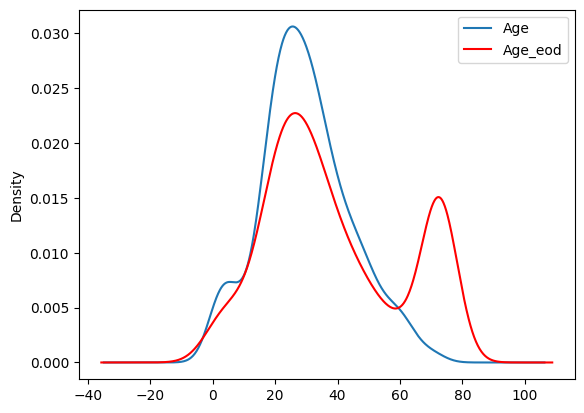

In [16]:
# AGE DISTRIBUTION

fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# End of distribution imputed variable
X_train['Age_eod'].plot(
    kind='kde',
    ax=ax,
    color='red'
)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

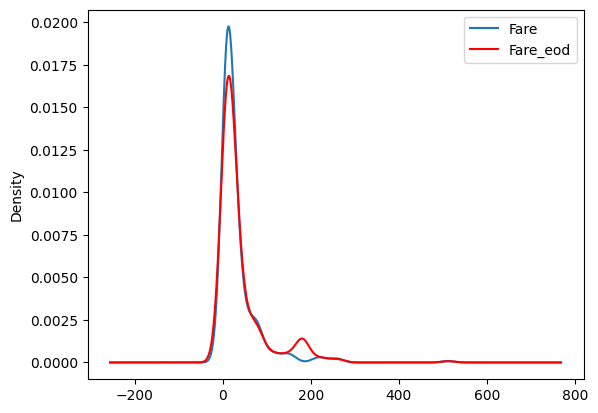

In [18]:
# FARE DISTRIBUTION

fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# End of distribution imputed variable
X_train['Fare_eod'].plot(
    kind='kde',
    ax=ax,
    color='red'
)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

In [19]:
# COVARIANCE AND CORRELATION

print("\nCovariance:")
print(X_train.cov(numeric_only=True))

print("\nCorrelation:")
print(X_train.corr(numeric_only=True))


Covariance:
                 Age         Fare     Family     Age_eod     Fare_eod
Age       204.349513    70.719262  -6.498901  204.349513    81.430646
Fare       70.719262  2448.197914  17.258917  -41.844228  2448.197914
Family     -6.498901    17.258917   2.735252   -6.534748    15.639094
Age_eod   204.349513   -41.844228  -6.534748  465.067186   -41.312676
Fare_eod   81.430646  2448.197914  15.639094  -41.312676  3383.464532

Correlation:
               Age      Fare    Family   Age_eod  Fare_eod
Age       1.000000  0.092644 -0.299113  1.000000  0.093092
Fare      0.092644  1.000000  0.208268 -0.039011  1.000000
Family   -0.299113  0.208268  1.000000 -0.183220  0.162567
Age_eod   1.000000 -0.039011 -0.183220  1.000000 -0.032934
Fare_eod  0.093092  1.000000  0.162567 -0.032934  1.000000
